In [ ]:
%load_ext autoreload
%autoreload 2
    
import sys
import os

# Add parent directory to path if needed
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))
from notebooks.config import *
from functools import partial


configure_matplotlib()
SAVE_FIGURES = True
fig_path = MERFISH_FIGURE_DIR
save_figure = partial(save_figure, dir_path=fig_path)

output_path = TMP_OUT_DIR

cpm_scl = CPM_SCL_MERFISH
plt.rcParams["image.cmap"] = CMAP_NAME

PROJECT_ROOT: /root/capsule
CODE_DIR: /root/capsule/code
CODE_DIR exists: True
Python path includes CODE_DIR: True


In [2]:

%load_ext autoreload
%autoreload 2
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import sys, os
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import processing, utils, plotting, heatmap
import pseudoclusters, test_structures
import spatial_cca,imputations

print(f"scanpy version: {sc.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
scanpy version: 1.11.3


/root/capsule/code/spatial_cca.py:119: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("D-V axis ($\mu$m)")
/root/capsule/code/spatial_cca.py:120: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel("A-P axis ($\mu$m)")
/root/capsule/code/spatial_cca.py:164: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel("M-L axis ($\mu$m)")


In [3]:
import imputations

In [4]:
MESH_DIR

'/root/capsule/data/mesh'

# Data Loading and Preprocessing

In [5]:
# Load mesh data
print("Loading mesh data...")
allmeshes = utils.load_mesh(MESH_DIR)
mesh = allmeshes['250513_LC_core_67_mesh_shrunk']
mesh.vertices /= 25  # Scale vertices to mm

# Load MERFISH data
print("Loading MERFISH data...")
filename = os.path.join(MERFISH_DATA_DIR, 'adata_mer_subset_2_6k.h5ad')
adata_mer = sc.read_h5ad(filename)
print(f"Original data shape: {adata_mer.shape}")

# Filter out cluster 5
adata_mer = adata_mer[adata_mer.obs['leiden']!='5',:]
print(f"After filtering: {adata_mer.shape}")

# Create UMAP embedding for visualization
print("Creating UMAP embedding...")
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI", random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)

Loading mesh data...
Loading MERFISH data...
Original data shape: (2651, 315)
After filtering: (2252, 315)
Creating UMAP embedding...


In [18]:
adata_mer.raw

# Perform CCA Analysis

In [6]:
# Prepare data for CCA
print("Performing CCA between gene expression and spatial coordinates...")
scl_multiplier = 25  # Scaling factor for spatial coordinates
S_mer = processing.get_hemi(adata_mer.obsm['spatial'],MESH_DIR)  # Process spatial coordinates

# Run CCA to find correlations between gene expression and spatial location
n_components = 2
cca, X_c, S_c, canonical_correlations = spatial_cca.perform_cca(
    adata_mer.X, 
    S_mer, 
    n_components=n_components, 
    scl_multiplier=scl_multiplier
)
print(f"Canonical correlations: {canonical_correlations}")

Performing CCA between gene expression and spatial coordinates...
Canonical correlations: [0.9292420438702444, 0.8019028227799995]


# Visualize CCA Results in Spatial Coordinates



Visualizing CCA component 1 in spatial coordinates...
Saving figure to: /root/capsule/output/figures/merfish/cca.svg


<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12283/2503196257.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("D-V axis ($\mu$m)")
/tmp/ipykernel_12283/2503196257.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel("A-P axis ($\mu$m)")
/tmp/ipykernel_12283/2503196257.py:56: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel("M-L axis ($\mu$m)")


Saving figure to: /root/capsule/output/figures/merfish/cca.png


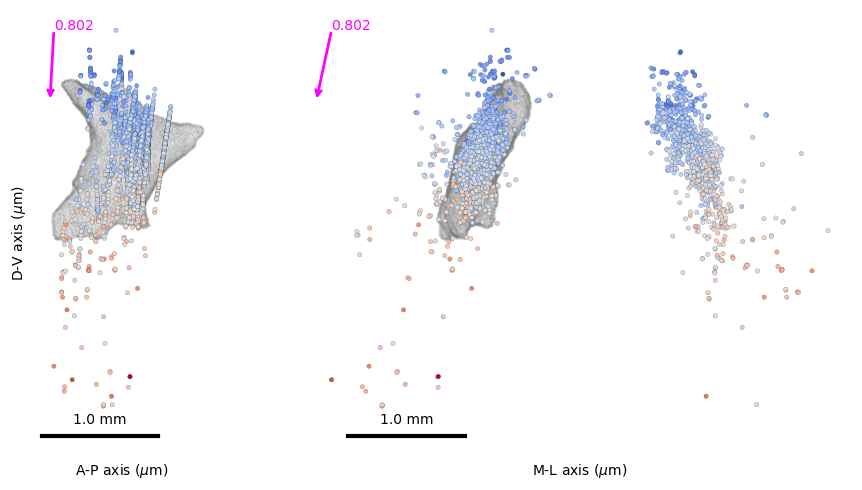

In [7]:
# Visualize CCA component 1 in sagittal and coronal views
print("Visualizing CCA component 1 in spatial coordinates...")
s = 10
k = 1  # Component to visualize (0-indexed)
scale_factor = 1 * scl_multiplier
vector = (cca.y_weights_[:, k])
vector_scaled = vector * scale_factor
allspatial = adata_mer.obsm['spatial'].copy()

fig, (ax1, ax2) = plt.subplots(
    1, 2,figsize=(10, 5),
    gridspec_kw={'width_ratios': [1, 4]}
)

# Sagittal view (A-P vs D-V)
# ax1.triplot(mesh.vertices.T[0], mesh.vertices.T[1], mesh.faces, color='lime', alpha=0.4)
ax1.scatter(mesh.vertices.T[0], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
# ax1.scatter(allspatial[:, 0], allspatial[:, 1], c=X_c[:, k], s=s, edgecolor='k', linewidth=0.1, cmap='Greys')
plotting.scatter_with_jitter(ax1, allspatial, X_c[:, k], direction='s', s=s, lw=0.1,scl_jitter=0.05, ascending=False, cmap ='coolwarm')
ax1.set_aspect('equal')

# Add vector arrow
start_point_all = np.min(allspatial, 0)
start_point = (start_point_all[0], start_point_all[1])
end_point = (start_point_all[0] + vector_scaled[0], start_point_all[1] + vector_scaled[1])
ax1.annotate('',xy=end_point,xytext=start_point,arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax1.text(start_point[0], start_point[1], np.around(canonical_correlations[k], 3).astype(str), color='magenta')
ax1.invert_yaxis()
ax1.set_ylabel("D-V axis ($\mu$m)")
ax1.set_xlabel("A-P axis ($\mu$m)")
xt = ax1.get_xticks(); yt = ax1.get_yticks()
ax1.set_xticks(xt); ax1.set_yticks(yt)
ax1.set_xticklabels(plotting.format_ticklabels(xt, scale=25))
ax1.set_yticklabels(plotting.format_ticklabels(yt, scale=25))
plotting.draw_scale_bar(ax1, length_px=40, linewidth=3, px_to_mm=25/1000)
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)
    
# Coronal view (M-L vs D-V)
# ax2.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, color='lime', alpha=0.4)
ax2.scatter(mesh.vertices.T[2], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
# ax2.scatter(vertices[:, 0], vertices[:, 1], c='gray', s=1, alpha=0.05, label='LC Core Mesh')
# sca = ax2.scatter(allspatial[:, 2], allspatial[:, 1], c=X_c[:, k], s=s, edgecolor='k', linewidth=0.1, cmap='coolwarm')
plotting.scatter_with_jitter(ax2, allspatial, X_c[:, k], direction='c', s=s, lw=0.1,scl_jitter=0.05, ascending=False, cmap ='coolwarm')
ax2.set_aspect('equal')

# Add vector arrow
start_point = (start_point_all[2], start_point_all[1])
end_point = (start_point_all[2] + vector_scaled[2], start_point_all[1] + vector_scaled[1])
ax2.annotate('',xy=end_point,xytext=start_point,arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax2.text(start_point[0], start_point[1], np.around(canonical_correlations[k], 3).astype(str), color='magenta')

ax2.invert_yaxis()
ax2.set_xlabel("M-L axis ($\mu$m)")
xt = ax2.get_xticks(); yt = ax2.get_yticks()
ax2.set_xticks(xt); ax2.set_yticks(yt)
ax2.set_xticklabels(plotting.format_ticklabels(xt, scale=25))
ax2.set_yticklabels(plotting.format_ticklabels(yt, scale=25))
plotting.draw_scale_bar(ax2, length_px=40, linewidth=3, px_to_mm=25*1e-3)
ax2.set_xticks([])
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)
fig.tight_layout()
save_figure("cca")
plt.show()

# which gene have weights

In [8]:
from scipy import sparse
k = 1
# gene weights (sklearn: cca.x_weights_)
w = cca.x_weights_[:, k]                     # shape: n_genes
genes = np.array(adata_mer.var_names)

df_w = pd.DataFrame({
    "gene": genes,
    "weight": w,
    "abs_weight": np.abs(w),
    "sign": np.sign(w)
}).sort_values("abs_weight", ascending=False)

top_pos = df_w[df_w["weight"] > 0].head(10)
top_neg = df_w[df_w["weight"] < 0].head(10)

print("Top + genes (by |weight|):")
print(top_pos[["gene","weight"]])
print("\nTop − genes (by |weight|):")
print(top_neg[["gene","weight"]])


# 2: gene–score correlations for the same component
X = adata_mer.X
if sparse.issparse(X):
    X = X.toarray()
score = X_c[:, k]                            # 2nd CCA score for X
# gene expression matrix
X = adata_mer.X
if sparse.issparse(X):
    X = X.toarray()

genes = np.array(adata_mer.var_names)

# compute Spearman correlation for each gene
corrs = []
for j in range(X.shape[1]):
    rho, _ = spearmanr(X[:, j], score)
    corrs.append(rho)

df_spearman = pd.DataFrame({
    "gene": genes,
    "spearman_corr_with_cca2": corrs,
    "abs_corr": np.abs(corrs)
}).sort_values("abs_corr", ascending=False)

print("\nTop genes by correlation with CCA2 score:")
print(df_spearman.head(10))

Top + genes (by |weight|):
       gene    weight
163    Nefm  0.313361
284    Tut4  0.272431
113  Gpr156  0.163616
216   Rab35  0.159897
224    Rorb  0.140923
156     Mog  0.129584
22     Brs3  0.125065
249  Slc4a4  0.124052
63    Cpne4  0.117563
292    Vwc2  0.111394

Top − genes (by |weight|):
        gene    weight
154     Map2 -0.154912
269    Tacr3 -0.152598
222   Rnf220 -0.145329
62   Cplane1 -0.132878
256   Snap25 -0.131701
241  Slc17a6 -0.130124
259   Sox2ot -0.121838
160   Necab2 -0.111211
311    Nr2f2 -0.110914
191     Pax5 -0.097224

Top genes by correlation with CCA2 score:
        gene  spearman_corr_with_cca2  abs_corr
269    Tacr3                 0.629108  0.629108
197     Pdyn                -0.615342  0.615342
183    Oprm1                -0.553200  0.553200
275  Tmem178                 0.521491  0.521491
281     Trhr                -0.507977  0.507977
31     Calcr                -0.472626  0.472626
194   Pde11a                -0.464908  0.464908
29     Calb2           

Saving figure to: /root/capsule/output/figures/merfish/cca2_top10_genes.svg
Saving figure to: /root/capsule/output/figures/merfish/cca2_top10_genes.png


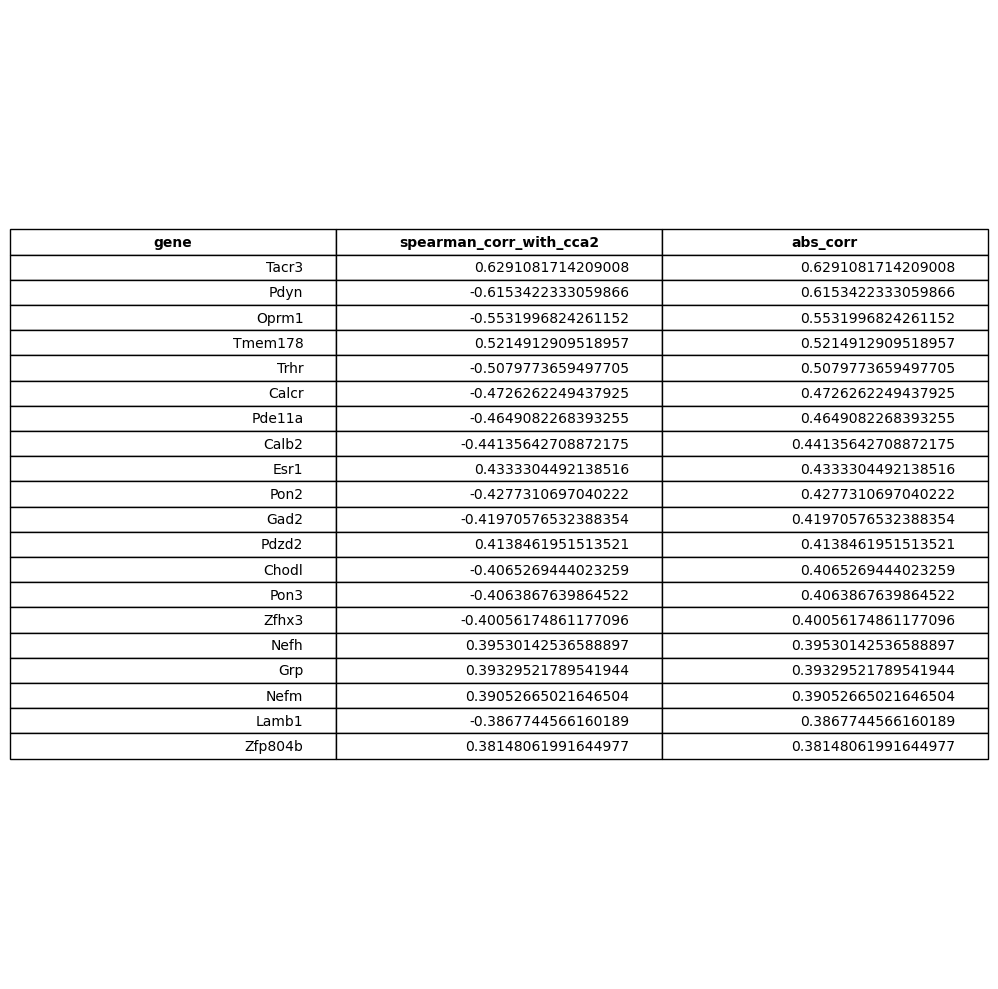

In [9]:
df_top = df_spearman.head(20).copy()
fig, ax = plt.subplots(figsize=(10,10))
ax.axis("off")
tbl = ax.table(
    cellText=df_top.values,
    colLabels=df_top.columns,
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
fig.tight_layout()
save_figure("cca2_top10_genes")

# Visualize CCA Component on UMAP


Visualizing CCA component on UMAP...
Saving figure to: /root/capsule/output/figures/merfish/merfish_umap.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_umap.png


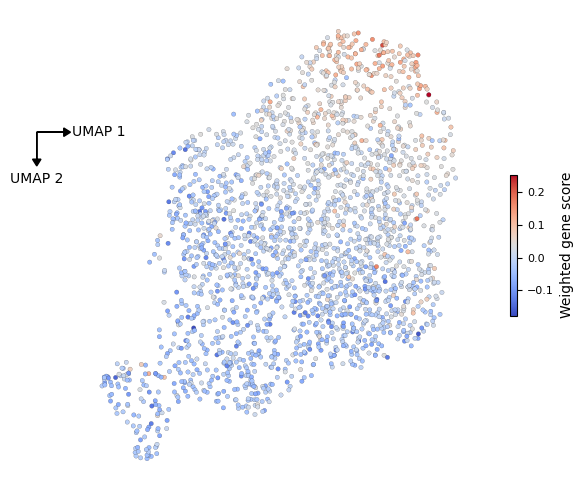

In [10]:
# Visualize CCA component on UMAP embedding
print("Visualizing CCA component on UMAP...")
s = 10
fs = 10
plt.figure(figsize=(7, 5))
ax = plt.gca()

sca = ax.scatter(adata_mer.obsm['X_umap'][:, 0], adata_mer.obsm['X_umap'][:, 1], 
                c=X_c[:, k], cmap='coolwarm', s=s, edgecolor='k', linewidth=0.1)
ax.set_aspect('equal')    
cbar = plt.colorbar(sca, ax=ax, label='Weighted gene score', shrink=0.3)

# Remove borders and ticks for clean appearance
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.invert_yaxis()

# Add UMAP axis labels
y0, x0 = np.min(adata_mer.obsm['X_umap'], 0)
y0 *= 1.4
x0 *= 0.8
ax.arrow(x0, y0, 1, 0, head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='k')
ax.arrow(x0, y0, 0, 1, head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='black')

ax.text(x0+1.05, y0, 'UMAP 1', va='center', ha='left', fontsize=fs)
ax.text(x0, y0+1.6, 'UMAP 2', va='bottom', ha='center', fontsize=fs)
plt.tight_layout()
save_figure("merfish_umap")
plt.show()

# Find Genes Correlated with CCA Direction


In [11]:
# Find genes correlated with the CCA direction
print("Finding genes correlated with CCA direction...")
direction_of_interest = -cca.y_weights_[:, 1]
direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
projected = adata_mer.obsm['spatial'] @ direction_norm

# Convert sparse matrix to numpy array if needed
if hasattr(adata_mer.X, 'toarray'):
    X = adata_mer.X.toarray()
else:
    X = np.array(adata_mer.X)

gene_names = adata_mer.var_names
results = []
for i, gene in enumerate(gene_names):
    expr = X[:, i]
    corr, pval = spearmanr(expr, projected)
    results.append((gene, corr, pval))

df_results = pd.DataFrame(results, columns=['gene', 'spearman_corr', 'p_value'])
df_results_sorted = df_results.sort_values(by='spearman_corr', key=lambda s: s.abs(), ascending=False)

print("Top 10 correlated genes:")
print(df_results_sorted.head(10))

Finding genes correlated with CCA direction...
Top 10 correlated genes:
        gene  spearman_corr        p_value
269    Tacr3      -0.517972  7.749654e-155
197     Pdyn       0.489750  3.498880e-136
275  Tmem178      -0.477582  1.153106e-128
183    Oprm1       0.449680  1.567966e-112
281     Trhr       0.412203   4.217461e-93
194   Pde11a       0.400310   1.960348e-87
86      Esr1      -0.377097   5.083481e-77
161     Nefh      -0.369869   6.027955e-74
99      Gad2       0.359137   1.589703e-69
119      Grp      -0.353472   2.932930e-67


# Gene Imputation and Visualization

In [12]:
# Load scRNA-seq data for imputation
print("Loading scRNA-seq data for imputation...")
adata_foo = sc.read_h5ad(os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_merbar_1-5k.h5ad"))
adata_sc = sc.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

# Subset MERFISH data to match genes in scRNA-seq
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer_foo = adata_mer[:, var_names]
print(f"Number of shared genes for imputation: {len(var_names)}")

# Impute MERFISH data
print("Imputing gene expression data...")
adata_mer_imputed = imputations.impute_mer_data(adata_sc, adata_mer_foo, k=200, n_hvg=None)
adata_mer_imputed.obsm['spatial'] = adata_mer.obsm['spatial'].copy()

Loading scRNA-seq data for imputation...
Number of shared genes for imputation: 303
Imputing gene expression data...
union!  1758


# Visualize Selected Genes in Spatial Coordinates

In [13]:
from matplotlib.colors import LinearSegmentedColormap
cmap_sele = plt.get_cmap(CMAP_NAME)
low_col = cmap_sele(0.0)   # RGBA for the "bottom" color
high_col = cmap_sele(1.0)  # RGBA for the "top" color
def make_edge_cmaps(base_cmap_name=CMAP_NAME):
    """Create two new colormaps based on the extremes of a given colormap."""
    cmap = plt.get_cmap(base_cmap_name)
    low = cmap(0.0)   # RGBA at bottom
    high = cmap(1.0)  # RGBA at top
    low_cmap = LinearSegmentedColormap.from_list("low_cmap", ["white", low])
    high_cmap = LinearSegmentedColormap.from_list("high_cmap", ["white", high])
    return low_cmap, high_cmap

low_cmap, high_cmap = make_edge_cmaps()

Visualizing selected genes...
Saving figure to: /root/capsule/output/figures/merfish/three_genes_examples.svg
Saving figure to: /root/capsule/output/figures/merfish/three_genes_examples.png


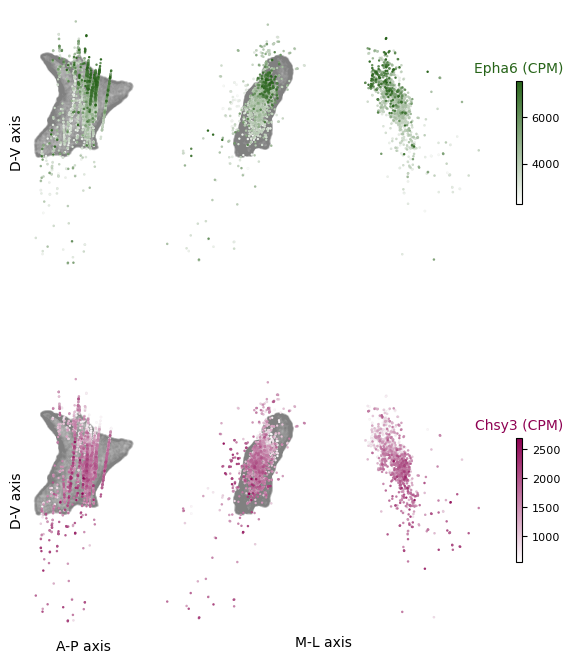

In [14]:
def plot_selected_genes(adata_imputed, selected_genes, mesh, colors=None, s=3):
    if colors is None:
        colors = [high_col, low_col]
        cmapnames = [high_cmap, low_cmap, ]
    
    fig, axes = plt.subplots(len(selected_genes), 2, figsize=(6, 8),
        gridspec_kw={'width_ratios': [1, 4]})
    
    for k, gene in enumerate(selected_genes):
        # Sagittal view
        ax = axes[k, 0]
        plotorder = np.argsort(adata_imputed[:, gene].X.flatten())
        # ax.triplot(mesh.vertices.T[0], mesh.vertices.T[1], mesh.faces, alpha=0.4, color='lime')
        ax.scatter(mesh.vertices.T[0], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
        sca = plotting.scatter_with_jitter(ax, 
                                     adata_imputed.obsm['spatial'][plotorder], 
                                     cpm_scl*adata_imputed[plotorder, gene].X.toarray(), 
                                     direction='s', s=s, lw=0.01,scl_jitter=0.05, ascending=False, cmap =cmapnames[k])
        # sca = ax.scatter(
        #     adata_imputed.obsm['spatial'][plotorder, 0],
        #     adata_imputed.obsm['spatial'][plotorder, 1],
        #     cmap=cmapnames[k], s=s, edgecolor='k', linewidth=0.01,
        #     c=cpm_scl*adata_imputed[plotorder, gene].X.toarray()
        # )
        ax.invert_yaxis()
        ax.set_ylabel("D-V axis")
        ax.set_xlabel("A-P axis") if k == len(selected_genes)-1 else ax.set_xlabel('')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # Coronal view
        ax = axes[k, 1]
        # ax.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha=0.4, color='lime')
        ax.scatter(mesh.vertices.T[2], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
        sca = plotting.scatter_with_jitter(ax, 
                                     adata_imputed.obsm['spatial'][plotorder], 
                                     cpm_scl*adata_imputed[plotorder, gene].X.toarray(), 
                                     direction='c', s=s, lw=0.01,scl_jitter=0.05, ascending=False, cmap =cmapnames[k])
        # sca = ax.scatter(
        #     adata_imputed.obsm['spatial'][plotorder, 2],
        #     adata_imputed.obsm['spatial'][plotorder, 1],
        #     cmap=cmapnames[k], s=s, edgecolor='k', linewidth=0.05,
        #     c=cpm_scl*adata_imputed[plotorder, gene].X.toarray()
        # )
        cbar = plt.colorbar(sca, ax=ax, shrink=0.3)
        cbar.ax.xaxis.set_label_position('top')
        cbar.ax.set_xlabel(f"{gene} (CPM)", ha='center', va='bottom', color=colors[k])
        ax.set_xlabel("M-L axis") if k == len(selected_genes)-1 else ax.set_xlabel('')
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.tight_layout()
    return fig

print("Visualizing selected genes...")
selected_genes = ['Epha6', 'Chsy3']
fig = plot_selected_genes(adata_mer_imputed, selected_genes, mesh)
save_figure("three_genes_examples")
plt.show()

# Generate Heatmap of Gene Expression


In [15]:
TMP_OUT_DIR

'/root/capsule/output'

Preparing data for heatmap visualization...
Using 21 available genes for heatmap
Creating gene expression heatmap...
Saving figure to: /root/capsule/output/figures/merfish/merfish_heatmap.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_heatmap.png


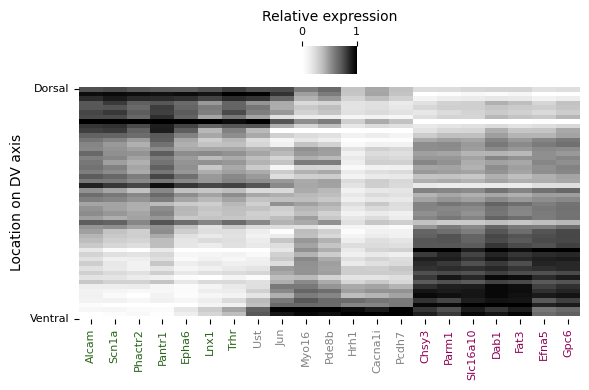

In [16]:
# Prepare data for heatmap visualization
print("Preparing data for heatmap visualization...")
k = 1
direction_of_interest = (cca.y_weights_[:, k]) 
direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
projected = adata_mer.obsm['spatial'] @ direction_norm

import pickle
output_file = os.path.join(TMP_OUT_DIR, 'allyourgenes.pkl')
allyourgenes = pickle.load(file = open(output_file,'rb'))

# Check gene availability
available_genes = [gene for gene in allyourgenes if gene in adata_mer_imputed.var_names]
print(f"Using {len(available_genes)} available genes for heatmap")

# Sort cells by position along the CCA direction
t_order = np.argsort(projected)
inputheatmap = adata_mer_imputed[:, available_genes].X.toarray()[t_order].T
ordered_data, row_order = heatmap.get_final_heatmap(inputheatmap, gene_reorder = False)

# Define color grouping for genes (for visualization)
T = int(len(row_order)/3)
tick_colors = []
for orig_idx in row_order:
    if orig_idx < T:
        tick_colors.append(high_col)
    elif orig_idx >= 2*T:
        tick_colors.append(low_col)
    else:
        tick_colors.append('gray')

# Create heatmap
print("Creating gene expression heatmap...")
plt.figure(figsize=(6, 4))
sns.heatmap(
    ordered_data.T,
    cmap='Greys',
    cbar_kws={
        'location': 'top',
        'label': 'Relative expression',
        'shrink': 0.3,
        'aspect': 2,
        'fraction': 0.1
    }
)

# Set xtick labels and colors
xtick_labels = [available_genes[l] for l in row_order]
xticks = plt.gca().get_xticks()
plt.xticks(ticks=xticks, labels=xtick_labels, rotation=90)
for tick, color in zip(plt.gca().get_xticklabels(), tick_colors):
    tick.set_color(color)

plt.ylabel('Location on DV axis')
q = 2  # How many labels to show on y-axis
plt.yticks(
    np.arange(q)*(ordered_data.shape[1]//(q-1))+0.5, 
    ['Dorsal', 'Ventral'], 
    rotation=0
)
plt.grid(False)
plt.tight_layout()
save_figure("merfish_heatmap")
plt.show()


# Impute Pseudoclusters from scRNA-seq to MERFISH

In [17]:
import pseudocluster_imputations 

In [18]:
output_file = os.path.join(os.path.dirname(fig_path), 'cellID_pc_0722.csv')

In [19]:
pseudocluster_imputations.impute_pseudocluster

<function imputations.impute_pseudocluster(adata_query, adata_ref, pc_dir, k=10, n_null=1000, per_cell_null=False, do_bootstrap=True, n_boot=500, epsilon=1e-10, weighted=True)>

In [20]:
common_genes_mer = np.intersect1d(adata_mer.var_names, adata_sc.var_names)
adata_mer = adata_mer[:,common_genes_mer]
imp_mer,conf_mer = pseudocluster_imputations.impute_pseudocluster(adata_mer, adata_sc, pc_dir = TMP_OUT_DIR, k=100)
adata_mer.obs['imputed pseudocluster']=imp_mer

using 303 genes to run the imputations!


/tmp/ipykernel_4033/1201293585.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_mer.obs['imputed pseudocluster']=imp_mer


In [21]:
scl_jitter = 0.05

conf_mer.keys()


dict_keys(['conf_power', 'ci_lower', 'ci_upper', 'pc_std'])

Saving figure to: /root/capsule/output/figures/merfish/merfish_pc.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_pc.png


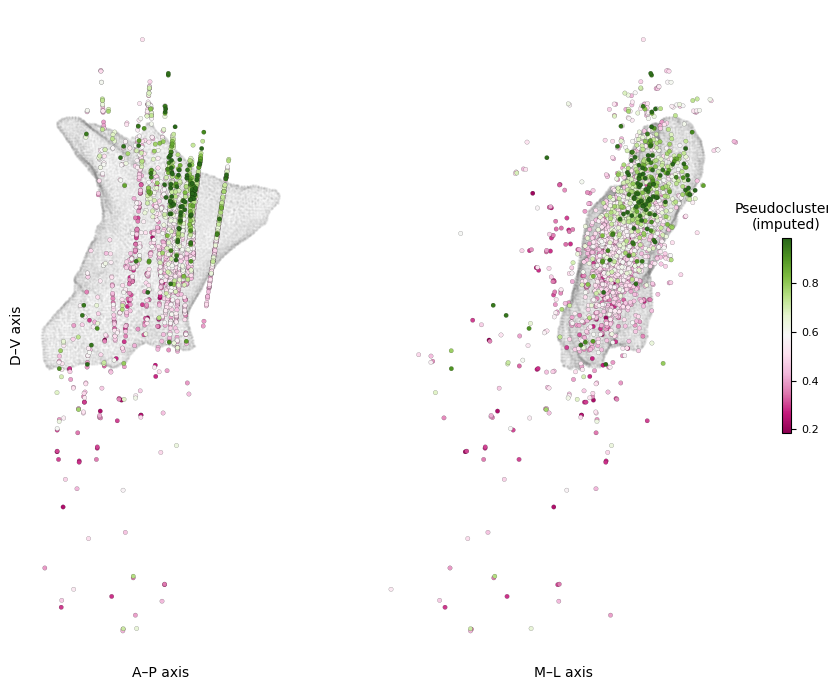

In [22]:

s = 10
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(9, 7),gridspec_kw={'width_ratios': [1, 2]})
# ——— Left: Sagittal view (direction='s') ———
plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
sca = plotting.scatter_with_jitter(ax1, S_mer, adata_mer.obs['imputed pseudocluster'], 
                             direction='s', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap ='PiYG')

ax1.set_aspect('equal')
ax1.set_ylabel("D–V axis")
ax1.set_xlabel("A–P axis")
ax1.set_xticks([]); ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)

# ——— Right: Coronal view (direction='c') ———
plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
sca = plotting.scatter_with_jitter(ax2, S_mer, adata_mer.obs['imputed pseudocluster'], 
                             direction='c',  s=s, lw=0.1,scl_jitter=scl_jitter, ascending=True, cmap ='PiYG')
cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel("Pseudoclusters\n(imputed)", ha='center', va='bottom')
ax2.set_aspect('equal')
ax2.set_xlabel("M–L axis")
ax2.set_xticks([]); ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)
    
fig.tight_layout()
save_figure("merfish_pc")
plt.show()

Saving figure to: /root/capsule/output/figures/merfish/merfish_pc_CI.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_pc_CI.png


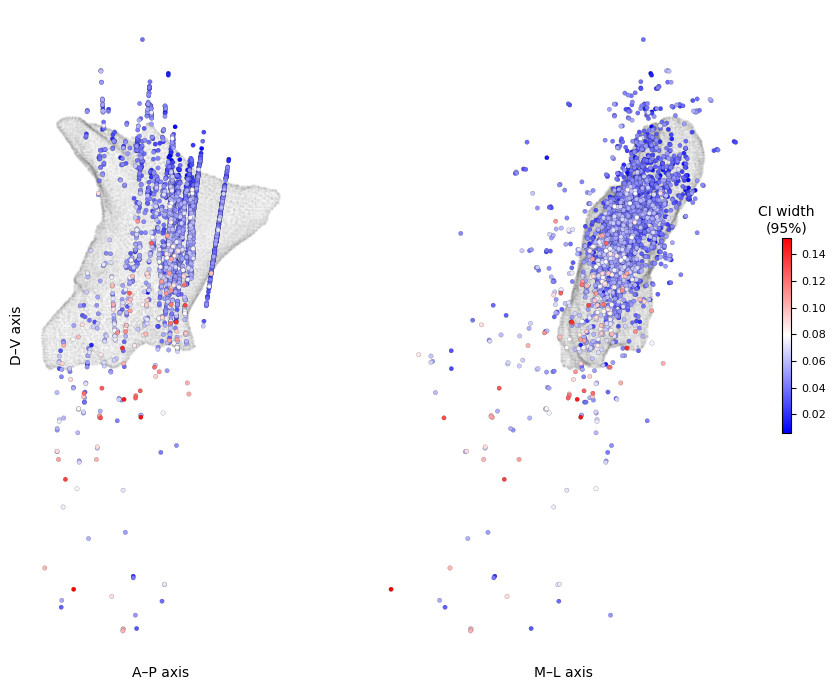

In [23]:
ci_width = conf_mer['ci_upper'] - conf_mer['ci_lower']
adata_mer.obs['pc_ci_width'] = ci_width

ci_width = conf_mer['ci_upper'] - conf_mer['ci_lower']
adata_mer.obs['pc_ci_width'] = ci_width

s = 10
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(9, 7),gridspec_kw={'width_ratios': [1, 2]})
plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
plotting.scatter_with_jitter(ax1, S_mer, ci_width, direction='s',  lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap ='bwr')
ax1.set_aspect('equal')
ax1.set_ylabel("D–V axis")
ax1.set_xlabel("A–P axis")
ax1.set_xticks([]); ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)

plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
sca = plotting.scatter_with_jitter(ax2, S_mer, ci_width, direction = 'c', s=s, lw=0.1, scl_jitter=scl_jitter, ascending=True, cmap ='bwr')
cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel("CI width\n(95%)", ha='center')
ax2.set_aspect('equal')
ax2.set_xlabel("M–L axis")
ax2.set_xticks([]); ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)
    
fig.tight_layout()
save_figure("merfish_pc_CI")

Saving figure to: /root/capsule/output/figures/merfish/merfish_confidence.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_confidence.png


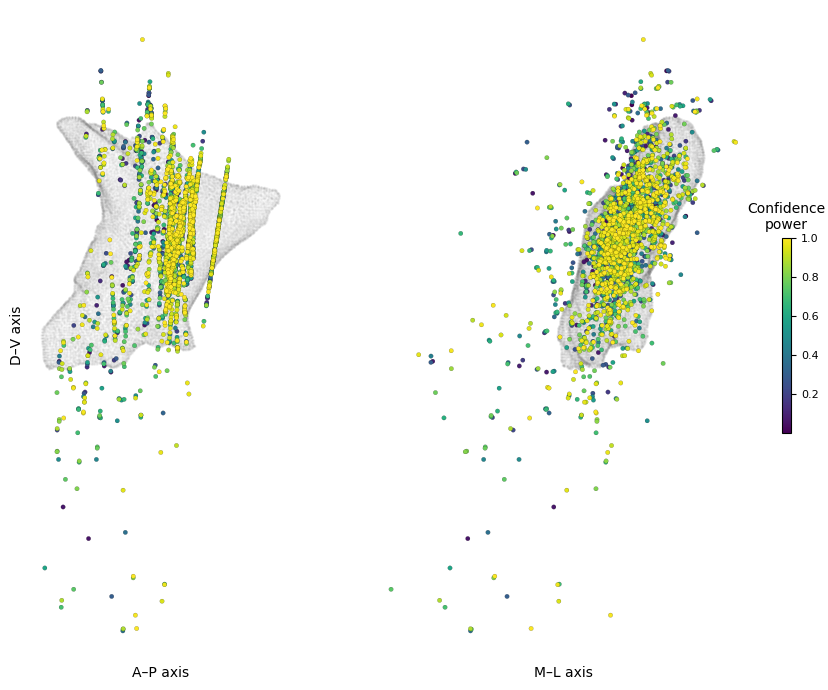

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(9, 7),gridspec_kw={'width_ratios': [1, 2]})
plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
plotting.scatter_with_jitter(ax1, S_mer, conf_mer['conf_power'],direction='s', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True)
ax1.set_aspect('equal')
ax1.set_ylabel("D–V axis")
ax1.set_xlabel("A–P axis")
ax1.set_xticks([]); ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)

plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
sca = plotting.scatter_with_jitter(ax2, S_mer, conf_mer['conf_power'],direction = 'c',lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True)
cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel("Confidence\npower", ha='center', va='bottom')
ax2.set_aspect('equal')
ax2.set_xlabel("M–L axis")
ax2.set_xticks([]); ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)
    
    
fig.tight_layout()

save_figure("merfish_confidence")

Saving figure to: /root/capsule/output/figures/merfish/merfish_pc_std.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_pc_std.png


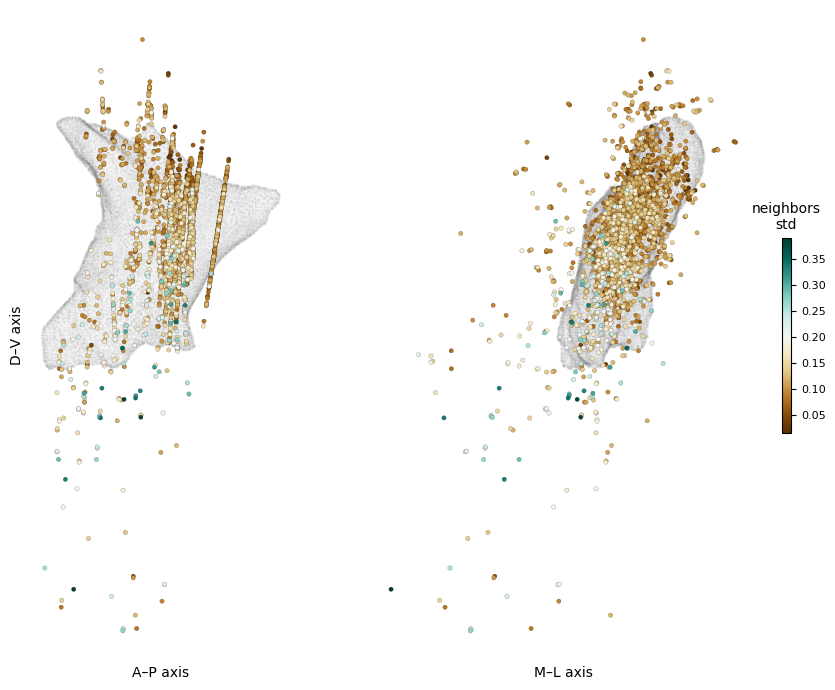

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(9, 7),gridspec_kw={'width_ratios': [1, 2]})
plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
plotting.scatter_with_jitter(ax1, S_mer, conf_mer['pc_std'],direction='s', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap ='BrBG')
ax1.set_aspect('equal')
ax1.set_ylabel("D–V axis")
ax1.set_xlabel("A–P axis")
ax1.set_xticks([]); ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)

plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
sca = plotting.scatter_with_jitter(ax2, S_mer, conf_mer['pc_std'],direction = 'c', s=s, lw=0.1, scl_jitter=scl_jitter, ascending=True, cmap ='BrBG')
cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel("neighbors\nstd", ha='center', va='bottom')
ax2.set_aspect('equal')
ax2.set_xlabel("M–L axis")
ax2.set_xticks([]); ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)
fig.tight_layout()
save_figure("merfish_pc_std")    

# scatter plot (btw DV axis and pseudocluster score)

Text(0, 0.5, 'DV axis coords')

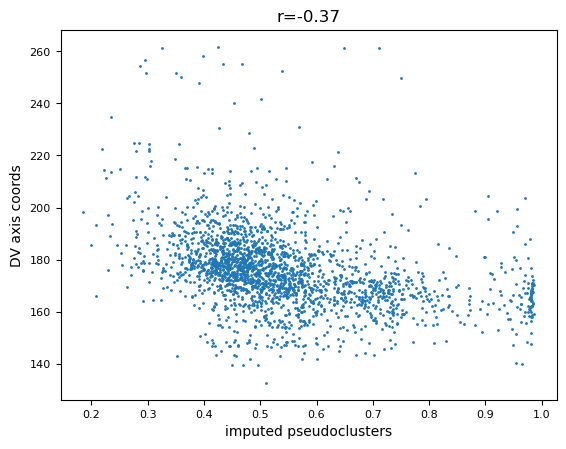

In [26]:
corrcoeff_dv_pc = np.corrcoef( adata_mer.obs['imputed pseudocluster'],S_mer[:,1])[0,1]

plt.scatter( adata_mer.obs['imputed pseudocluster'] ,S_mer[:,1], s=1)
plt.title(f'r={np.around(corrcoeff_dv_pc,2)}')
plt.xlabel('imputed pseudoclusters')
plt.ylabel('DV axis coords')

Text(0, 0.5, 'vector projection')

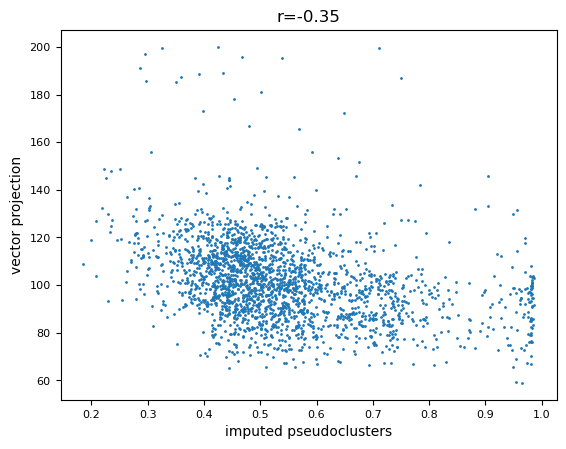

In [27]:
# direction_of_interest = -cca.y_weights_[:, 1]
# direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
# projected = adata_mer.obsm['spatial'] @ direction_norm


corrcoeff_dv_pc = np.corrcoef(adata_mer.obs['imputed pseudocluster'],projected)[0,1]

plt.scatter(adata_mer.obs['imputed pseudocluster'], projected,s=1)
plt.title(f'r={np.around(corrcoeff_dv_pc,2)}')
plt.xlabel('imputed pseudoclusters')
plt.ylabel('vector projection')

# Visualize Retroseq DE Genes


Visualizing retroseq DE genes...
Saving figure to: /root/capsule/output/figures/merfish/retro_DE_distrb_s.svg


/tmp/ipykernel_4033/73909210.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
/tmp/ipykernel_4033/73909210.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
/tmp/ipykernel_4033/73909210.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotti

Saving figure to: /root/capsule/output/figures/merfish/retro_DE_distrb_s.png


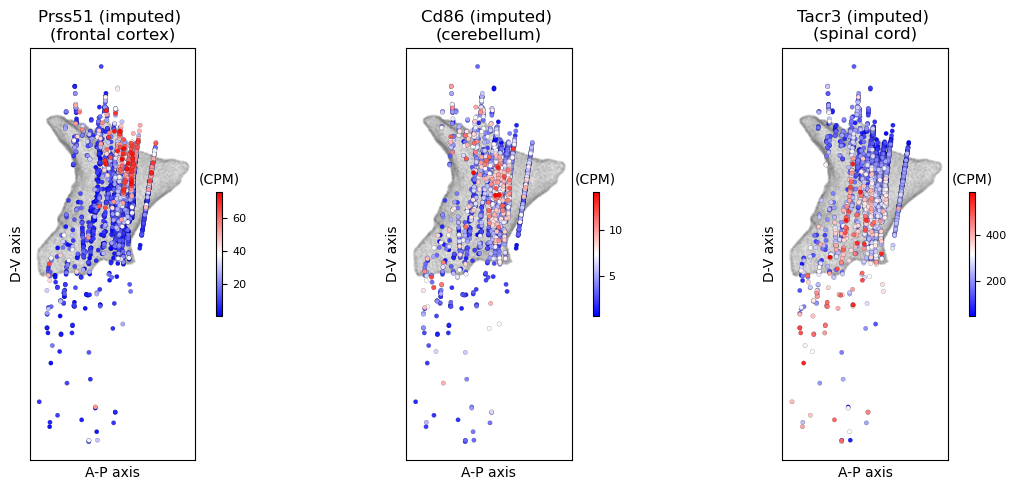

/tmp/ipykernel_4033/73909210.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
/tmp/ipykernel_4033/73909210.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
/tmp/ipykernel_4033/73909210.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotti

Saving figure to: /root/capsule/output/figures/merfish/retro_DE_distrb_c.svg
Saving figure to: /root/capsule/output/figures/merfish/retro_DE_distrb_c.png


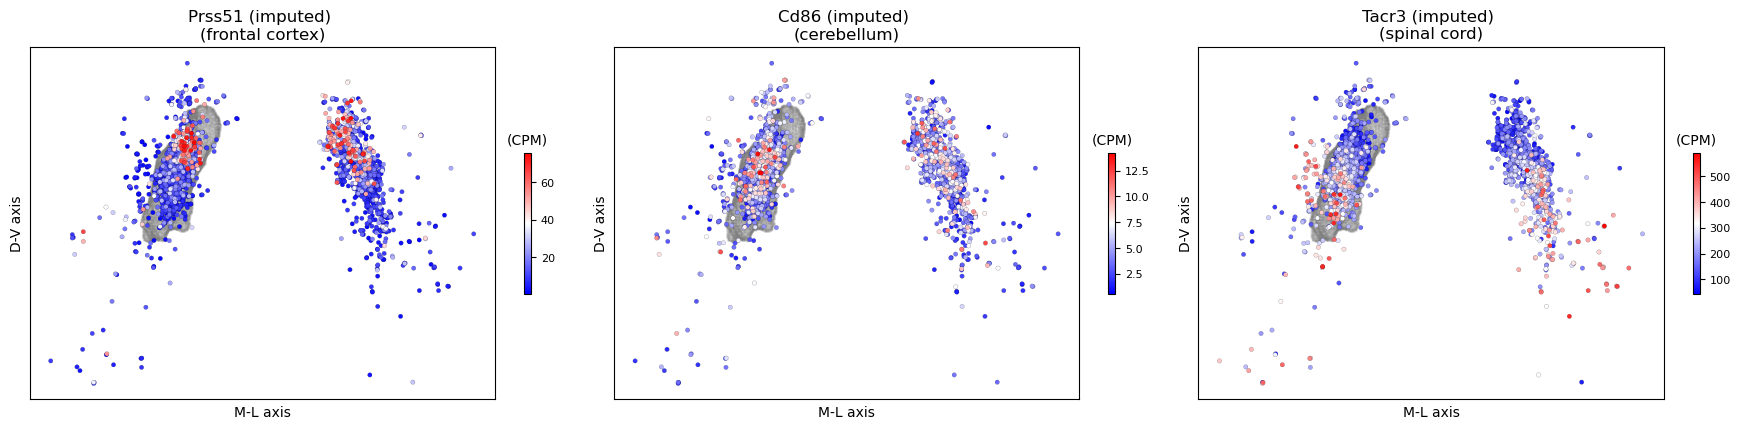

In [ ]:
# Visualize retroseq DE genes
print("Visualizing retroseq DE genes...")
retro_DE_genes = np.array([['Prss51',
  'Mbl2',
  'Ptgs2',
  'Tlr5',
  'Scnn1a',
  'Adcy8',
  'Tph2',
  'Csta2',
  'Vrk2',
  'Cyct'], # frontal cortex
                         [ 'Cd86',
  'Slc25a48',
  'Slpi',
  'Efemp1',
  'Ms4a4c',
  'Chrna2',
  'Pdgfrb',
  'Mcm2',
  'Rasef',
  'Tmem270'],  # cerebellum
                          ['Tacr3',
  'Tshr',
  'Syndig1',
  'Tshz2',
  'Glra3',
  'Chsy3',
  'Rspo2',
  'Esr1',
  'Rbfox3',
  'Pcdh7']]) # spinal cord

# Define projection sites
projectionsite_list = ['frontal cortex', 'cerebellum', 'spinal cord']

# Visualize first set of genes
genes_i_like = retro_DE_genes[:,0]

# Add imputed gene values to the original data
adata_mer = imputations.replace_imputedvalues(adata_mer, adata_mer_imputed, genes_i_like)

coords = allspatial.copy()
# Sagittal view
s = 10
fig, axes = plt.subplots(1, 3, squeeze=False, figsize=(12, 5))
axes = axes.flatten()
for i, gene in enumerate(genes_i_like):
    ax = axes[i]    
    color_values = adata_mer.obs[f'imput_{gene}']*cpm_scl
    neworder = np.argsort(color_values)
    plotting.plot_mesh(ax, allmeshes, direction='s', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
                             direction='s', s=s, scl_jitter=scl_jitter, ascending=True, cmap ='bwr')
    cbar = plt.colorbar(sca, ax=ax, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("(CPM)", ha='center', va='bottom')    
    ax.set_ylabel("D-V axis")
    ax.set_xlabel("A-P axis")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{gene} (imputed) \n({projectionsite_list[i]})')
    ax.grid(False)

fig.tight_layout()    
save_figure("retro_DE_distrb_s")
plt.show()

# Coronal view
fig, axes = plt.subplots(1, 3, squeeze=False, figsize=(18, 5))
axes = axes.flatten()
for i, gene in enumerate(genes_i_like):
    ax = axes[i]
    color_values = adata_mer.obs[f'imput_{gene}']*cpm_scl
    neworder = np.argsort(color_values)
    plotting.plot_mesh(ax, allmeshes, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
                             direction='c', s=s, scl_jitter=scl_jitter, ascending=True, cmap ='bwr')
    cbar = plt.colorbar(sca, ax=ax, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel(f"(CPM)", ha='center', va='bottom')    
    ax.set_ylabel("D-V axis")
    ax.set_xlabel("M-L axis")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{gene} (imputed) \n({projectionsite_list[i]})')
    ax.grid(False)

fig.tight_layout() 
save_figure("retro_DE_distrb_c")
plt.show()

# complete!

In [29]:
print("Analysis complete! All visualizations have been saved to:", fig_path)

Analysis complete! All visualizations have been saved to: /root/capsule/output/figures/merfish


In [30]:
fig_path


'/root/capsule/output/figures/merfish'